# Code for plots Fig. S3

In [4]:
# import libraries
import numpy as np
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler
%matplotlib inline
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
import numpy.ma as ma
from sklearn.neighbors import NearestNeighbors
import datajoint as dj
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from multiprocessing import Pool
import sys,os,inspect

# import modules

currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from single_neuron import Neuron_modulated, Neuron_peths, Labels
from utilities import format_axs

## Fig S3A
### Example neurons: Outcome selective, Stimulus responsive, Outcome*Choice, Choice selective

In [5]:
%matplotlib inline
def neuron_profile_raster_plot(neuron_key):
    
    peths_entry = Neuron_peths() & neuron_key
    
    peths = peths_entry.fetch('peths')[0]
    combinations = peths_entry.fetch('combinations')[0]
    nr_combinations = len(combinations)
    nr_alignments = len(peths[0])
    nr_timepoints = len(peths[0][0][0])
    x_time = peths_entry.fetch('time')[0]
    
    colors_dict = {(1,0):'tab:cyan',
                   (0,1):'tab:olive',
                   (0,0):'tab:gray',
                   (1,1):'tab:orange'}
    
    alignments = ['stimulus','choice']
    assert len(alignments) == nr_alignments
    assert len(combinations) == nr_combinations
    
    fig, axs = plt.subplots(1,2)  
    fig.set_figwidth(6)
    fig.set_figheight(2.25)
    min_ax = []
    max_ax = []
    min_nr_trials = []
    for i,combination in enumerate(combinations):
        # print('combination',combination)
        combination_tuple=(combination[0],combination[1])
        for j,alignment in enumerate(alignments):
            min_nr_trials.append(len(peths[i][j]))
            vecMean = np.mean(peths[i][j],axis=0)
            assert len(vecMean) == nr_timepoints
            st = np.std(peths[i][j],axis=0)
            vecSem = st/np.sqrt(len(peths[i][j]))
            
            min_ax.append(np.min(vecMean-vecSem))
            max_ax.append(np.max(vecMean+vecSem))
            axs[j].plot(x_time, vecMean,color=colors_dict[combination_tuple])
            axs[j].axvline(x=0, color='black', linestyle='dashed')
            axs[j].fill_between(x_time, vecMean-vecSem, 
                                      vecMean+vecSem,alpha=0.2,
                                      color=colors_dict[combination_tuple])
            
                
            axs[j].spines["top"].set_visible(False)
            axs[j].spines["right"].set_visible(False)
            axs[j].spines["bottom"].set_linewidth(2)
            axs[j].spines["left"].set_linewidth(2)
            axs[j].set_xlabel('Time to %s onset (s)'%alignment)
            axs[j].set_ylabel('$\Delta F/ F$')
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            if j == 1:
                axs[j].get_yaxis().set_visible(False)
                axs[j].spines["left"].set_visible(False)

    min_ax = np.min(min_ax) - 0.01
    max_ax = np.max(max_ax) + 0.01
    for ax in axs:
        ax.set_ylim(min_ax,max_ax)
        
    plt.tight_layout()
    plt.show()
    
    xticks = axs[j].get_xticks()[2:-2]
    tick_idx = [np.where(x_time> tick)[0][0] for tick in xticks]
    min_nr_trials = np.min(min_nr_trials)
    fig2, axs = plt.subplots(1,2)
    
    for j,alignment in enumerate(alignments):
        stacked = np.vstack([peths[i][j] for i in range(nr_combinations)])
        row_counter = 0
        for i,combination in enumerate(combinations):
            combination_tuple=(combination[0],combination[1])
            colormap = LinearSegmentedColormap.from_list('', [(0, "white"), (1, colors_dict[combination_tuple])])
            nr_trials = len(peths[i][j])
            indices = np.arange(nr_trials)
            np.random.shuffle(indices)
            shuffled = peths[i][j][indices]
            stacked[row_counter:row_counter+nr_trials] = shuffled
            masked_array = ma.masked_array(stacked, mask=np.zeros_like(stacked, dtype=bool))
            rows_to_unmask = [i for i in range(row_counter,row_counter+nr_trials,1)]
            for idx in range(len(stacked)):
                if idx not in rows_to_unmask:
                    masked_array[idx] = ma.masked
            row_counter += nr_trials
            axs[j].imshow(masked_array,interpolation='nearest',cmap=colormap,
                          vmin=min_ax+0.01,vmax=max_ax-0.01)
        axs[j].axvline(x=15, color='black', linestyle='dashed')
        axs[j].spines["top"].set_visible(False)
        axs[j].spines["right"].set_visible(False)
        axs[j].set_xticks(tick_idx)
        #axs[j].set_xticklabels([])
        axs[j].set_xlabel('Time to %s onset (s)'%alignment)
        axs[j].set_ylabel('# Trial')
        axs[j].spines["bottom"].set_linewidth(2)
        axs[j].spines["left"].set_linewidth(2)
        axs[j].invert_yaxis()

    plt.tight_layout()
    plt.show()
    return fig, fig2

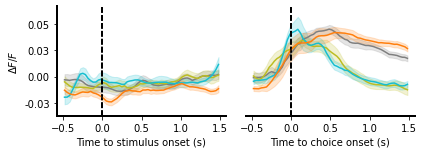

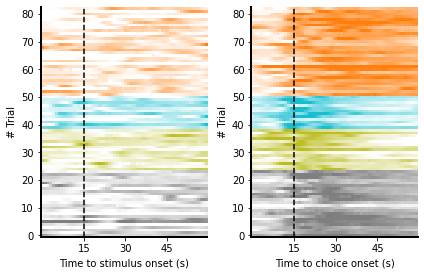

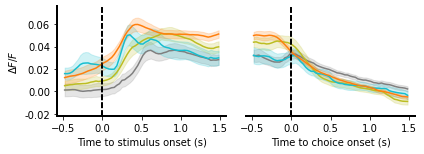

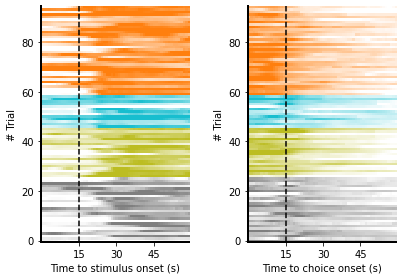

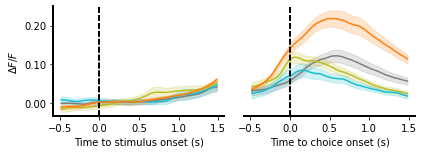

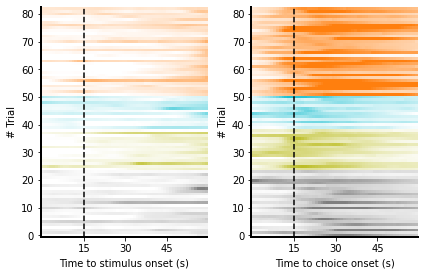

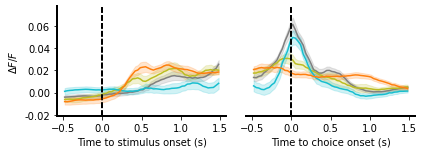

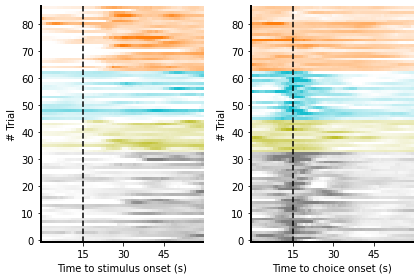

In [6]:
neuron_example_supp = [{'name': '1dsc_apr2023',
    'animal_id': 'BK4926_L',
    'neuron_id': 43,
    'experimental_timepoint': 'gentest_2',
    'session_id': 55},{'name': '1dsc_apr2023',
  'animal_id': 'BK4926_L',
  'neuron_id': 219,
  'experimental_timepoint': 'categorization_4',
  'session_id': 53},{'name': '1dsc_apr2023',
    'animal_id': 'BK4926_L',
    'mask_id': 391,
    'experimental_timepoint': 'gentest_2',
    'trace_type': 'dff',
    'session_id': 55},{'name': '1dsc_apr2023',
    'animal_id': 'BK4933_LR',
    'neuron_id': 283,
    'experimental_timepoint': 'gentest_1',
    'session_id': 31}] 
for neuron_key in neuron_example_supp:
    neuron_profile_raster_plot(neuron_key)

## Fig S3B
Corresponds to schematic illustration of t-SNE analysis pipeline

## Fig S3C
### Cummulative variance explained as a function of number of principal components

100%|██████████| 7936/7936 [03:08<00:00, 42.14it/s]


X.shape (6462, 480)
X_z.shape (6462, 480)


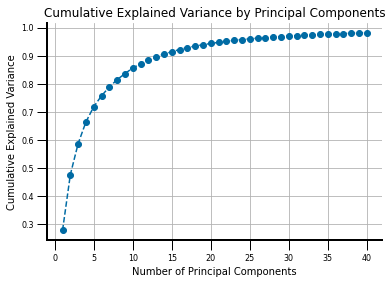

pc_ (21, 6462)
X_pca (6462, 480)


In [7]:
# gather single neuron response profiles
neuron_keys = (Neuron_peths()).fetch(dj.key)

X = [] # nr neurons x response profile in window for combinations concatenated 
selected_keys = []
# concatenate responses for each trial type and window (event onset)
for i in tqdm(range(len(neuron_keys))):
    entry = Neuron_peths() & neuron_keys[i]
    
    label = (Labels & neuron_keys[i]).fetch('label')[0]
    if label != 'not modulated':
        entry = Neuron_peths() & neuron_keys[i]
        selected_keys.append(neuron_keys[i])
        peths = entry.fetch('peths')[0]
        time = entry.fetch('time')[0]
        
        vec_profile = []
        for c in range(4):
         # window alignments
            vec_windows = []
            for window in range(2):
                vec_windows.append(np.mean(peths[c][window],axis=0))
            vec_profile.append(np.concatenate(vec_windows))
            
        X.append(np.concatenate(vec_profile))
        
X=np.array(X)
print('X.shape',X.shape)
nr_neurons = X.shape[0]
#z scoring each neuron
m_X = np.mean(X,1)
st_X = np.std(X,1)
m_X = m_X[:,np.newaxis]
st_X = st_X[:,np.newaxis]
X_z = (X-m_X)/st_X

print('X_z.shape',X_z.shape)

# run pca on response profiles
pca = PCA(n_components=40) # 9 components explain > 80% variance
pca.fit(X_z.T)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig,axs = plt.subplots()
axs = format_axs(axs)
axs.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
axs.set_title('Cumulative Explained Variance by Principal Components')
axs.set_xlabel('Number of Principal Components')
axs.set_ylabel('Cumulative Explained Variance')
axs.grid(True)
plt.show()

nr_components = np.where(cumulative_variance >0.95)[0][0] # 0.95
# restrict pca fit to components explaining 95% variance
pca = PCA(n_components=nr_components)
pca.fit(X_z.T)

pc_ = pca.components_
print('pc_',pc_.shape)
pc_time_profiles = pc_@ X_z

# define X (z scored) in new basis of principal components (profile in time)
X_pca = np.zeros_like(X_z)
for i in range(nr_neurons):
    neuron_pc = pc_[:,i] # neuron pc weights
    
    vec = neuron_pc @ pc_time_profiles
    X_pca[i] = vec
    
print('X_pca',X_pca.shape)

# Initialize t-SNE model
random_state=42
tsne_model = TSNE(n_components=2,n_iter=1000,random_state=random_state)

# Fit and transform the data to 2 dimensions for visualization
tsne_results = tsne_model.fit_transform(X_pca)


## Fig S3D
###

For n_clusters = 2, silhouette score = 0.3625508248806
p-value: 0.158
For n_clusters = 4, silhouette score = 0.38860756158828735
p-value: 0.446
For n_clusters = 6, silhouette score = 0.37554389238357544
p-value: 0.196
For n_clusters = 8, silhouette score = 0.38663896918296814
p-value: 0.144
For n_clusters = 10, silhouette score = 0.3760835528373718
p-value: 0.562
For n_clusters = 12, silhouette score = 0.37932682037353516
p-value: 0.583
For n_clusters = 14, silhouette score = 0.38008585572242737
p-value: 0.595
For n_clusters = 16, silhouette score = 0.371599018573761
p-value: 0.862
For n_clusters = 18, silhouette score = 0.3798462450504303
p-value: 0.105
For n_clusters = 20, silhouette score = 0.3732435703277588
p-value: 0.272
For n_clusters = 22, silhouette score = 0.37663203477859497
p-value: 0.179
For n_clusters = 24, silhouette score = 0.3722062408924103
p-value: 0.858
For n_clusters = 26, silhouette score = 0.3772650361061096
p-value: 0.129
For n_clusters = 28, silhouette score = 

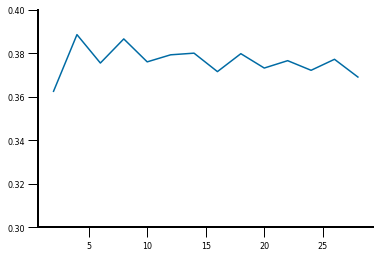

In [8]:
def k_clustering(data,n_clusters):
    kmeans_perm = KMeans(n_clusters=n_clusters, init='k-means++',
                         max_iter=300, n_init=10, random_state=42)
    labels = kmeans_perm.fit_predict(data)
    score = silhouette_score(data, labels)
    return score
    
# Range of clusters to evaluate
nr_cores = 4
n_clusters_range = range(2,30,2)# To store silhouette scores for each number of clusters
silhouette_scores = []
x_clusters = []
for n_clusters in n_clusters_range:
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10)    # Fit the model to the data
    kmeans.fit(tsne_results)    # Obtain cluster labels for each data point
    labels = kmeans.labels_    # Evaluate silhouette score
    score = silhouette_score(tsne_results, labels)
    silhouette_scores.append(score)    
    x_clusters.append(n_clusters)
    # Permutation test parallelize
    n_permutations = 1000
    permuted_data = [np.random.permutation(tsne_results) for _ in range(n_permutations)]
    with Pool(nr_cores) as pool:
        args = [(permuted_data[m],n_clusters) for m in range(n_permutations)]
        permuted_scores = pool.starmap(k_clustering, args)
    
    # Calculate p-value
    p_value = (np.sum(permuted_scores >= score) + 1) / (n_permutations + 1)
    print(f"For n_clusters = {n_clusters}, silhouette score = {score}")
    print(f"p-value: {p_value:.3f}")

    
fig,axs = plt.subplots()
axs = format_axs(axs)
axs.plot(x_clusters,silhouette_scores)
axs.set_ylim(0.3,0.4)
plt.show()
